# Heterogeneity Plots

Generates the four figures referenced in the methodology chapter:

- `het_compute_latency.png` — per-sample compute-latency histogram (ms)
- `het_comm_bandwidth.png` — bandwidth histogram (kbps, log-x)
- `het_round_durations.png` — 2-panel: per-round compute time and 2-way comm time
- `het_total_duration.png` — total per-round duration (compute + comm)

Run from repo root.

## Knobs

In [21]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy.stats import gaussian_kde

TRACE_PATH    = Path("../traces/client_device_capacity.json")
OUT_DIR       = Path("result/heterogeneity")
NUM_SAMPLES   = 200          # examples per client per epoch
LOCAL_EPOCHS  = 1
PAYLOAD_KB    = 3174.0        # ModernBERT-base + rank-8 LoRA adapter
APPLY_UNIT_FIX = True         # True: 2 * 8 * KB / kbps  (correct)
                              # False: 2 * KB / kbps     (current code in timing.py)
SAVE_DPI      = 200           # PNG export DPI
KDE_SUBSAMPLE = 20_000        # cap for KDE fit (scipy gaussian_kde is O(n*m))

OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
})


def sci_y_axis(ax):
    """Force y-axis tick labels to 10^-x scientific notation."""
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))


def kde_curve(x: np.ndarray, log_x: bool, n_grid: int = 400, rng_seed: int = 0):
    """Fit a Gaussian KDE on (log-)x and return (xs, density) for plotting."""
    rng = np.random.default_rng(rng_seed)
    if len(x) > KDE_SUBSAMPLE:
        x = rng.choice(x, size=KDE_SUBSAMPLE, replace=False)
    if log_x:
        # Fit in log10 space, then convert back; density transform: f(x)=g(u)/(x ln 10)
        u = np.log10(x)
        kde = gaussian_kde(u)
        u_grid = np.linspace(u.min(), u.max(), n_grid)
        xs = 10.0 ** u_grid
        dens = kde(u_grid) / (xs * np.log(10.0))
    else:
        kde = gaussian_kde(x)
        xs = np.linspace(x.min(), x.max(), n_grid)
        dens = kde(xs)
    return xs, dens

## Load trace

In [22]:
with open(TRACE_PATH) as f:
    raw = json.load(f)

comp_ms   = np.array([v["computation"]   for v in raw.values()], dtype=float)
comm_kbps = np.array([v["communication"] for v in raw.values()], dtype=float)

mask = (comp_ms > 0) & (comm_kbps > 0)
comp_ms, comm_kbps = comp_ms[mask], comm_kbps[mask]

def fmt_q(x: np.ndarray) -> str:
    q = np.quantile(x, [0.05, 0.5, 0.95])
    return f"p5={q[0]:.1f} | med={q[1]:.1f} | p95={q[2]:.1f} | n={len(x):,}"

print(f"profiles: {len(comp_ms):,}")
print("compute_ms :", fmt_q(comp_ms))
print("comm_kbps  :", fmt_q(comm_kbps))

profiles: 500,000
compute_ms : p5=136.0 | med=314.0 | p95=793.3 | n=500,000
comm_kbps  : p5=1393.2 | med=6074.7 | p95=51663.0 | n=500,000


## Figure 1 — compute-latency distribution

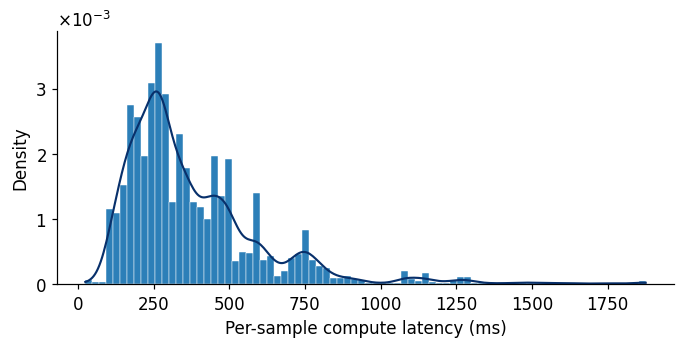

saved: result\heterogeneity\het_compute_latency.png


In [23]:
fig, ax = plt.subplots(figsize=(6.5, 3.3))
ax.hist(comp_ms, bins=80, density=True,
        color="#2c7fb8", edgecolor="white", linewidth=0.3)
xs, dens = kde_curve(comp_ms, log_x=False)
ax.plot(xs, dens, color="#08306b", linewidth=1.4)
ax.set_xlabel("Per-sample compute latency (ms)")
ax.set_ylabel("Density")
sci_y_axis(ax)
fig.tight_layout()
out = OUT_DIR / "het_compute_latency.png"
fig.savefig(out, dpi=SAVE_DPI, bbox_inches="tight")
plt.show()
print(f"saved: {out}")

## Figure 2 — bandwidth distribution

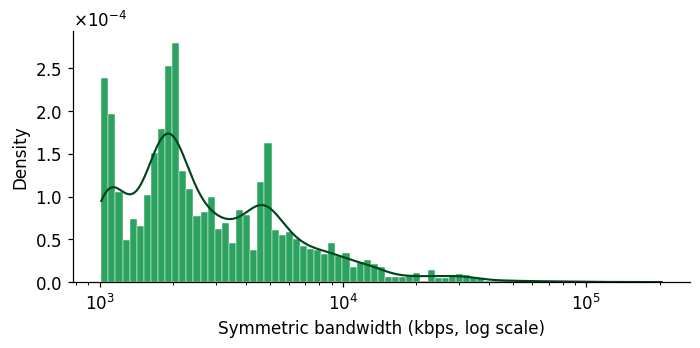

saved: result\heterogeneity\het_comm_bandwidth.png


In [24]:
fig, ax = plt.subplots(figsize=(6.5, 3.3))
bins = np.logspace(np.log10(comm_kbps.min()), np.log10(comm_kbps.max()), 80)
ax.hist(comm_kbps, bins=bins, density=True,
        color="#2ca25f", edgecolor="white", linewidth=0.3)
xs, dens = kde_curve(comm_kbps, log_x=True)
ax.plot(xs, dens, color="#00441b", linewidth=1.4)
ax.set_xscale("log")
ax.set_xlabel("Symmetric bandwidth (kbps, log scale)")
ax.set_ylabel("Density")
sci_y_axis(ax)
fig.tight_layout()
out = OUT_DIR / "het_comm_bandwidth.png"
fig.savefig(out, dpi=SAVE_DPI, bbox_inches="tight")
plt.show()
print(f"saved: {out}")

## Figure 3 — per-round duration components

Compute time assumes `NUM_SAMPLES × LOCAL_EPOCHS` per round. Communication time
is two-way over a `PAYLOAD_KB` LoRA adapter; the unit-fix toggle controls
whether KB→kbits conversion is applied (the current `timing.py` code skips it).

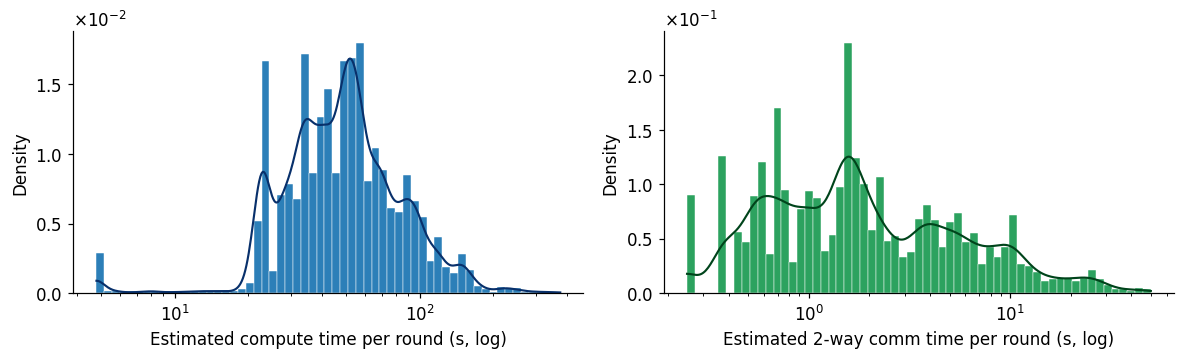

saved: result\heterogeneity\het_round_durations.png


In [25]:
compute_s   = comp_ms * NUM_SAMPLES * LOCAL_EPOCHS / 1000.0
unit_factor = 8.0 if APPLY_UNIT_FIX else 1.0
comm_s      = 2.0 * unit_factor * PAYLOAD_KB / comm_kbps

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

ax = axes[0]
bins_c = np.logspace(np.log10(max(compute_s.min(), 1e-3)),
                     np.log10(compute_s.max()), 60)
ax.hist(compute_s, bins=bins_c, density=True,
        color="#2c7fb8", edgecolor="white", linewidth=0.3)
xs, dens = kde_curve(compute_s, log_x=True)
ax.plot(xs, dens, color="#08306b", linewidth=1.4)
ax.set_xscale("log")
ax.set_xlabel("Estimated compute time per round (s, log)")
ax.set_ylabel("Density")
sci_y_axis(ax)

ax = axes[1]
bins_n = np.logspace(np.log10(max(comm_s.min(), 1e-3)),
                     np.log10(comm_s.max()), 60)
ax.hist(comm_s, bins=bins_n, density=True,
        color="#2ca25f", edgecolor="white", linewidth=0.3)
xs, dens = kde_curve(comm_s, log_x=True)
ax.plot(xs, dens, color="#00441b", linewidth=1.4)
ax.set_xscale("log")
ax.set_xlabel("Estimated 2-way comm time per round (s, log)")
ax.set_ylabel("Density")
sci_y_axis(ax)

fig.tight_layout()
out = OUT_DIR / "het_round_durations.png"
fig.savefig(out, dpi=SAVE_DPI, bbox_inches="tight")
plt.show()
print(f"saved: {out}")

## Figure 4 — total per-round duration

Total duration = compute time + communication time.

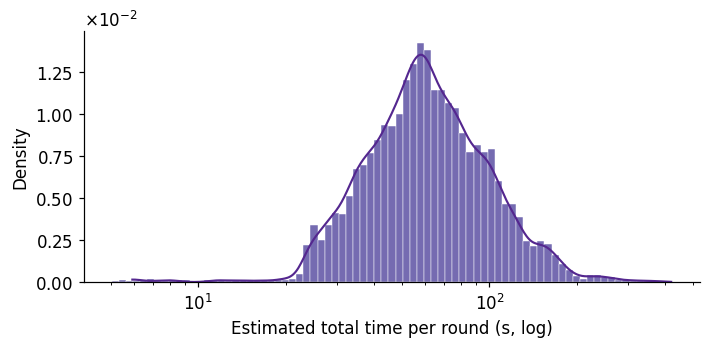

saved: result\heterogeneity\het_total_duration.png


In [26]:
total_s = compute_s + comm_s

fig, ax = plt.subplots(figsize=(6.5, 3.3))
bins = np.logspace(np.log10(max(total_s.min(), 1e-3)), np.log10(total_s.max()), 80)
ax.hist(total_s, bins=bins, density=True,
        color="#756bb1", edgecolor="white", linewidth=0.3)
xs, dens = kde_curve(total_s, log_x=True)
ax.plot(xs, dens, color="#54278f", linewidth=1.4)
ax.set_xscale("log")
ax.set_xlabel("Estimated total time per round (s, log)")
ax.set_ylabel("Density")
sci_y_axis(ax)
fig.tight_layout()
out = OUT_DIR / "het_total_duration.png"
fig.savefig(out, dpi=SAVE_DPI, bbox_inches="tight")
plt.show()
print(f"saved: {out}")

In [27]:
# Print percentiles: p5 | med | p75 |p95 | n
q = np.quantile(total_s, [0.05, 0.5, 0.75, 0.95])
print(f"total round time (s): p5={q[0]:.1f} | med={q[1]:.1f} | p75={q[2]:.1f} | p95={q[3]:.1f} | n={len(total_s):,}")

total round time (s): p5=35.1 | med=76.5 | p75=107.5 | p95=176.2 | n=500,000


## Save summary

In [28]:
summary = {
    "num_profiles": int(len(comp_ms)),
    "compute_ms":   {f"{q}": float(np.quantile(comp_ms, q))
                     for q in (0.05, 0.5, 0.95)},
    "comm_kbps":    {f"{q}": float(np.quantile(comm_kbps, q))
                     for q in (0.05, 0.5, 0.95)},
    "assumptions": {
        "num_samples":  NUM_SAMPLES,
        "local_epochs": LOCAL_EPOCHS,
        "payload_kb":   PAYLOAD_KB,
        "unit_fix":     APPLY_UNIT_FIX,
    },
}
out = OUT_DIR / "summary.json"
out.write_text(json.dumps(summary, indent=2))
print(f"saved: {out}")
summary

saved: result\heterogeneity\summary.json


{'num_profiles': 500000,
 'compute_ms': {'0.05': 136.0, '0.5': 314.0, '0.95': 793.3},
 'comm_kbps': {'0.05': 1393.2277009351494,
  '0.5': 6074.702413493102,
  '0.95': 51663.04256805362},
 'assumptions': {'num_samples': 200,
  'local_epochs': 1,
  'payload_kb': 3174.0,
  'unit_fix': True}}